In [1]:
!pip install ucimlrepo

# 1. Ambil data dari UCI Repo CDC Diabetes Health Indicators

In [1]:
from ucimlrepo import fetch_ucirepo 

# Fetch dataset
cdc_diabetes_health_indicators = fetch_ucirepo(id=891) 

# Data
X = cdc_diabetes_health_indicators.data.features 
y = cdc_diabetes_health_indicators.data.targets 

# Metadata
print(cdc_diabetes_health_indicators.metadata) 

# Variable information
print(cdc_diabetes_health_indicators.variables)

{'uci_id': 891, 'name': 'CDC Diabetes Health Indicators', 'repository_url': 'https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators', 'data_url': 'https://archive.ics.uci.edu/static/public/891/data.csv', 'abstract': 'The Diabetes Health Indicators Dataset contains healthcare statistics and lifestyle survey information about people in general along with their diagnosis of diabetes. The 35 features consist of some demographics, lab test results, and answers to survey questions for each patient. The target variable for classification is whether a patient has diabetes, is pre-diabetic, or healthy. ', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Tabular', 'Multivariate'], 'num_instances': 253680, 'num_features': 21, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Sex', 'Age', 'Education Level', 'Income'], 'target_col': ['Diabetes_binary'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_

# 2. Cek bentuk datanya

In [2]:
print("Shape X:", X.shape)
print("Shape y:", y.shape)

display(X.head())
display(y.head())

Shape X: (253680, 21)
Shape y: (253680, 1)


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,1,1,1,40,1,0,0,0,0,1,...,1,0,5,18,15,1,0,9,4,3
1,0,0,0,25,1,0,0,1,0,0,...,0,1,3,0,0,0,0,7,6,1
2,1,1,1,28,0,0,0,0,1,0,...,1,1,5,30,30,1,0,9,4,8
3,1,0,1,27,0,0,0,1,1,1,...,1,0,2,0,0,0,0,11,3,6
4,1,1,1,24,0,0,0,1,1,1,...,1,0,2,3,0,0,0,11,5,4


,Diabetes_binary
0,0
1,0
2,0
3,0
4,0


In [3]:
print("Kolom fitur:")
print(X.columns.tolist())

print("\nKolom target:")
print(y.columns.tolist())

Kolom fitur:
['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

Kolom target:
['Diabetes_binary']


# 3. Gabungkan X dan y agar lebih mudah dianalisis

In [5]:
import pandas as pd

df = pd.concat([X, y], axis=1)

display(df.head())
print(df.info())

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,1,1,1,40,1,0,0,0,0,1,...,0,5,18,15,1,0,9,4,3,0
1,0,0,0,25,1,0,0,1,0,0,...,1,3,0,0,0,0,7,6,1,0
2,1,1,1,28,0,0,0,0,1,0,...,1,5,30,30,1,0,9,4,8,0
3,1,0,1,27,0,0,0,1,1,1,...,0,2,0,0,0,0,11,3,6,0
4,1,1,1,24,0,0,0,1,1,1,...,0,2,3,0,0,0,11,5,4,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   HighBP                253680 non-null  int64
 1   HighChol              253680 non-null  int64
 2   CholCheck             253680 non-null  int64
 3   BMI                   253680 non-null  int64
 4   Smoker                253680 non-null  int64
 5   Stroke                253680 non-null  int64
 6   HeartDiseaseorAttack  253680 non-null  int64
 7   PhysActivity          253680 non-null  int64
 8   Fruits                253680 non-null  int64
 9   Veggies               253680 non-null  int64
 10  HvyAlcoholConsump     253680 non-null  int64
 11  AnyHealthcare         253680 non-null  int64
 12  NoDocbcCost           253680 non-null  int64
 13  GenHlth               253680 non-null  int64
 14  MentHlth              253680 non-null  int64
 15  PhysHlth              253680 non-n

## Cek missing value:

In [6]:
df.isnull().sum()

HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
Diabetes_binary         0
dtype: int64

## Cek distribusi target:

In [7]:
target_col = y.columns[0]

print("Target column:", target_col)
print(df[target_col].value_counts())
print(df[target_col].value_counts(normalize=True))

Target column: Diabetes_binary
Diabetes_binary
0    218334
1     35346
Name: count, dtype: int64
Diabetes_binary
0    0.860667
1    0.139333
Name: proportion, dtype: float64


## 4. Pakai fitur yang mudah dijelaskan

In [8]:
selected_features = [
    "HighBP",
    "HighChol",
    "BMI",
    "Smoker",
    "PhysActivity",
    "Fruits",
    "Veggies",
    "GenHlth",
    "MentHlth",
    "PhysHlth",
    "Age",
    "Sex"
]

X_selected = df[selected_features]
y_selected = df[target_col]

## Cek datanya:

In [9]:
display(X_selected.head())
display(y_selected.head())

,HighBP,HighChol,BMI,Smoker,PhysActivity,Fruits,Veggies,GenHlth,MentHlth,PhysHlth,Age,Sex
0,1,1,40,1,0,0,1,5,18,15,9,0
1,0,0,25,1,1,0,0,3,0,0,7,0
2,1,1,28,0,0,1,0,5,30,30,9,0
3,1,0,27,0,1,1,1,2,0,0,11,0
4,1,1,24,0,1,1,1,2,3,0,11,0


0    0
1    0
2    0
3    0
4    0
Name: Diabetes_binary, dtype: int64

## 5. Split data training dan testing

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y_selected,
    test_size=0.2,
    random_state=42,
    stratify=y_selected
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (202944, 12)
Testing data: (50736, 12)


## 6. Train model Random Forest

In [11]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Kenapa pakai class_weight="balanced"?
Karena dataset kesehatan sering tidak seimbang. Biasanya jumlah orang non-diabetes lebih banyak daripada orang diabetes.

## 7. Evaluasi model

In [12]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8219410280668559
ROC-AUC: 0.7490288703984553

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.91      0.90     43667
           1       0.32      0.26      0.29      7069

    accuracy                           0.82     50736
   macro avg       0.60      0.58      0.59     50736
weighted avg       0.81      0.82      0.81     50736


Confusion Matrix:
[[39899  3768]
 [ 5266  1803]]


## 8. Cek feature importance

In [13]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": selected_features,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

display(feature_importance)

,feature,importance
2,BMI,0.247120
10,Age,0.171774
7,GenHlth,0.125896
9,PhysHlth,0.105062
0,HighBP,0.096141
8,MentHlth,0.080420
1,HighChol,0.044712
5,Fruits,0.028619
3,Smoker,0.028176
11,Sex,0.025799


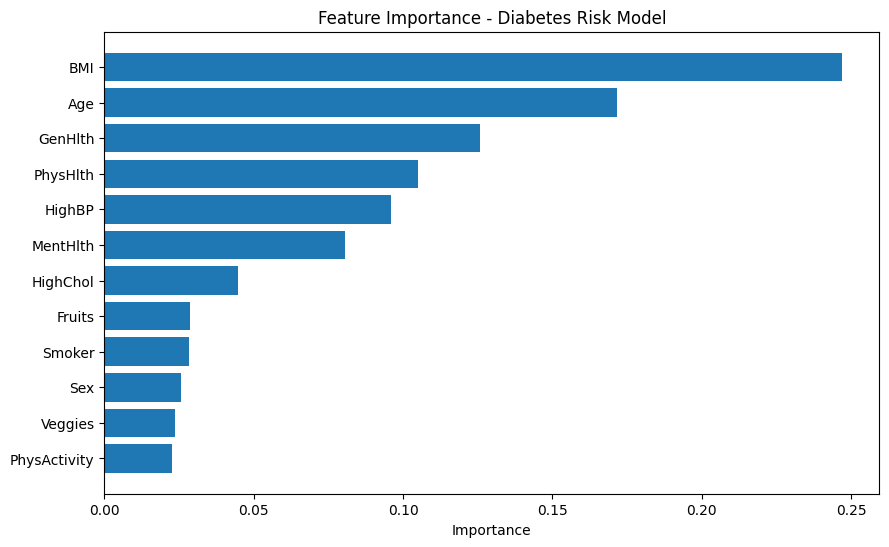

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(feature_importance["feature"], feature_importance["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Feature Importance - Diabetes Risk Model")
plt.show()

## 9. Simpan model

In [15]:
import joblib
import os

os.makedirs("model", exist_ok=True)

joblib.dump(model, "model/diabetes_model.pkl")
joblib.dump(selected_features, "model/selected_features.pkl")

['model/selected_features.pkl']

## 10. Coba prediksi satu data dummy

In [16]:
sample_input = pd.DataFrame([{
    "HighBP": 1,
    "HighChol": 1,
    "BMI": 32,
    "Smoker": 1,
    "PhysActivity": 0,
    "Fruits": 0,
    "Veggies": 1,
    "GenHlth": 4,
    "MentHlth": 5,
    "PhysHlth": 10,
    "Age": 9,
    "Sex": 1
}])

prediction = model.predict(sample_input)[0]
probability = model.predict_proba(sample_input)[0][1]

print("Prediction:", prediction)
print("Diabetes probability:", probability)

Prediction: 1
Diabetes probability: 0.5182504005104885


In [17]:
if probability < 0.35:
    risk_level = "Low"
elif probability < 0.65:
    risk_level = "Moderate"
else:
    risk_level = "High"

print("Risk level:", risk_level)

Risk level: Moderate
